## Correccion Examen Parcial 1

**Simulación de Procesos Financieros, ITESO**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)

---
## Ejercicio 1. Volatilidad móvil y activación del contrato

El contrato se activa solo si la **volatilidad móvil de 20 días, anualizada**, nunca supera el 20%.

Procedimiento:
1. Rendimientos logarítmicos diarios: $r_t = \ln(S_t / S_{t-1})$
2. Desviación estándar móvil con ventana de 20 días
3. Anualizar multiplicando por $\sqrt{252}$
4. Revisar si alguna observación excede 0.20

In [2]:
datos = pd.read_excel("ex1_01.xlsx").set_index("Día")
datos.head()

,Ruta A,Ruta B
Día,,
0,100.0,100.0
1,101.2,101.3
2,100.4,99.9
3,102.0,101.8
4,101.5,100.6


In [3]:
log_ret = np.log(datos / datos.shift(1))
vol = log_ret.rolling(20).std() * np.sqrt(252)

resumen = pd.DataFrame({
    "Vol máxima": vol.max(),
    "Vol mínima": vol.min(),
    "Días sobre 20%": (vol > 0.20).sum(),
    "Días medidos": vol.notna().sum(),
    "Contrato": np.where(vol.max() <= 0.20, "Se activa", "No se activa")
})
resumen

,Vol máxima,Vol mínima,Días sobre 20%,Días medidos,Contrato
Ruta A,0.182838,0.149182,0,40,Se activa
Ruta B,0.341465,0.251356,40,40,No se activa


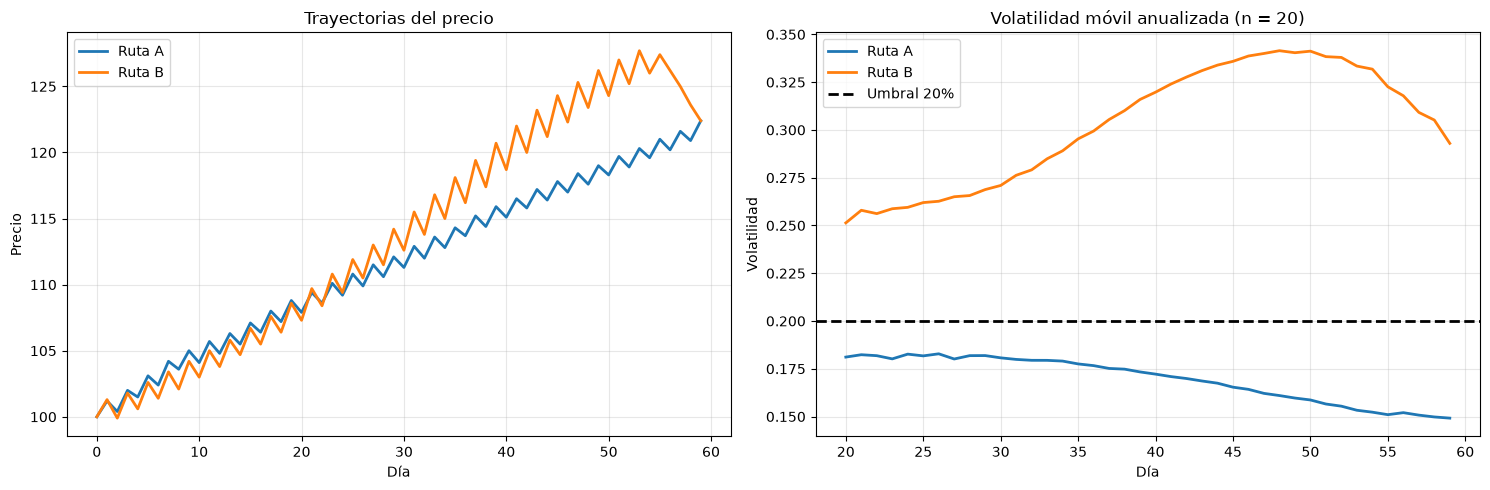

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

datos.plot(ax=axes[0], lw=2)
axes[0].set_title("Trayectorias del precio")
axes[0].set_ylabel("Precio")
axes[0].grid(alpha=0.3)

vol.plot(ax=axes[1], lw=2)
axes[1].axhline(0.20, color="black", ls="--", lw=2, label="Umbral 20%")
axes[1].set_title("Volatilidad móvil anualizada (n = 20)")
axes[1].set_ylabel("Volatilidad")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Respuesta

**El contrato se activa con la Ruta A.** Su volatilidad móvil se mantiene siempre por debajo del umbral, con un máximo de 18.3%, y además va bajando a lo largo del periodo. La Ruta B lo excede en todos los días medidos, con un máximo de 34.2%.

Lo interesante es que las dos rutas terminan en el mismo precio, 122.4, y suben de forma parecida. La diferencia no está en el destino sino en el camino: la Ruta A avanza con oscilaciones diarias pequeñas y regulares, mientras la Ruta B da saltos más grandes y hacia el final incluso retrocede. El rendimiento acumulado no distingue entre ambas; la volatilidad sí.

---
## Ejercicio 2. GBM con parámetros que cambian en el tiempo

En el GBM estándar $r$ y $\sigma$ son constantes. Aquí cambian según el día, así que se simula paso a paso y en cada día se usa el valor vigente:

$$S_{t} = S_{t-1} \exp\left[\left(r_t + \mu_t - \tfrac{\sigma_t^2}{2}\right)\Delta t + \sigma_t\sqrt{\Delta t}\,Z_t\right], \qquad \Delta t = \tfrac{1}{252}$$

### Justificación de cada modificación

**Día 30: tasas al 8%.** La tasa vive en el drift, así que $r_t$ pasa de 0.05 a 0.08 a partir del día 30 y se queda así hasta el final. Es un cambio permanente: una decisión de política monetaria no se revierte sola. El efecto es una pendiente de crecimiento más pronunciada, sin cambiar la dispersión.

**Días 50 a 69: volatilidad al 40%.** La volatilidad aparece en dos lugares de la fórmula, en el término aleatorio $\sigma_t\sqrt{\Delta t}\,Z_t$ y en la corrección de Itô $-\sigma_t^2/2$, y ambos se actualizan. Se aplica durante 20 días hábiles y luego regresa a 20%. El abanico de trayectorias se abre en esa ventana y ya no se cierra: aunque la volatilidad vuelva a la normalidad, la dispersión acumulada queda incorporada en cada trayectoria.

**Días 120 a 124: anuncio de productos.** Es un choque de nivel, no de incertidumbre: el enunciado habla de reacciones fuertemente positivas, o sea de dirección. Se modela con un drift adicional $\mu_t$ solo durante los 5 días hábiles de esa semana, sin tocar la volatilidad. Se usa $\mu_{\text{anuncio}} = 2.0$ anualizado, que produce un alza acumulada cercana al 4% en la semana. Después de esa semana $\mu_t$ vuelve a cero.

> **Nota.** Esta simulación es bajo la medida real, no la riesgo-neutra. Un drift extra conocido de antemano sería una oportunidad de arbitraje bajo $Q$, así que estos resultados sirven para proyección y análisis de escenarios, no para valuar derivados.

In [5]:
S0, T, n, M = 100, 1, 252, 10_000
dt = T / n

# Parámetros de cada régimen
r_base, r_nueva     = 0.05, 0.08
sigma_base, sigma_alta = 0.20, 0.40
mu_anuncio = 2.0

dia_tasas          = 30
dia_vol_ini, dia_vol_fin   = 50, 70     # días 50 a 69: 20 días hábiles
dia_anun_ini, dia_anun_fin = 120, 125   # días 120 a 124: 1 semana hábil

In [6]:
def r_dia(t):
    return r_nueva if t >= dia_tasas else r_base

def sigma_dia(t):
    return sigma_alta if dia_vol_ini <= t < dia_vol_fin else sigma_base

def mu_dia(t):
    return mu_anuncio if dia_anun_ini <= t < dia_anun_fin else 0.0

In [7]:
np.random.seed(42)

Z = np.random.normal(0, 1, (M, n))
S = np.zeros((M, n + 1))
S[:, 0] = S0

for t in range(1, n + 1):
    r, s, m = r_dia(t), sigma_dia(t), mu_dia(t)
    S[:, t] = S[:, t-1] * np.exp((r + m - 0.5*s**2)*dt + s*np.sqrt(dt)*Z[:, t-1])

ST = S[:, -1]
print(f"E[S_T]           : {ST.mean():.2f}")
print(f"Mediana S_T      : {np.median(ST):.2f}")
print(f"IC 95% (P2.5-P97.5): [{np.percentile(ST, 2.5):.2f}, {np.percentile(ST, 97.5):.2f}]")

E[S_T]           : 112.14
Mediana S_T      : 109.58
IC 95% (P2.5-P97.5): [70.44, 168.83]


### Validación

Para comprobar que cada cambio entró donde debía, se mide la volatilidad realizada en cada tramo y el alza durante la semana del anuncio.

In [8]:
log_ret_sim = np.diff(np.log(S), axis=1)

# El rendimiento del día t está en la posición t-1
tramos = [(1, 30, "Días 1-29"), (30, 50, "Días 30-49"),
          (50, 70, "Días 50-69 (vol 40%)"), (70, 120, "Días 70-119"),
          (120, 125, "Días 120-124 (anuncio)"), (125, 253, "Días 125-252")]

validacion = pd.DataFrame({
    "Tramo": [t[2] for t in tramos],
    "Vol realizada": [log_ret_sim[:, a-1:b-1].std() * np.sqrt(252) for a, b, _ in tramos]
})
print(validacion.round(4).to_string(index=False))

alza = S[:, dia_anun_fin - 1].mean() / S[:, dia_anun_ini - 1].mean() - 1
print(f"\nAlza promedio en la semana del anuncio: {alza*100:.2f}%")

                 Tramo  Vol realizada
             Días 1-29         0.2006
            Días 30-49         0.2006
  Días 50-69 (vol 40%)         0.3999
           Días 70-119         0.2002
Días 120-124 (anuncio)         0.1999
          Días 125-252         0.2000

Alza promedio en la semana del anuncio: 4.24%


### Gráfica de trayectorias

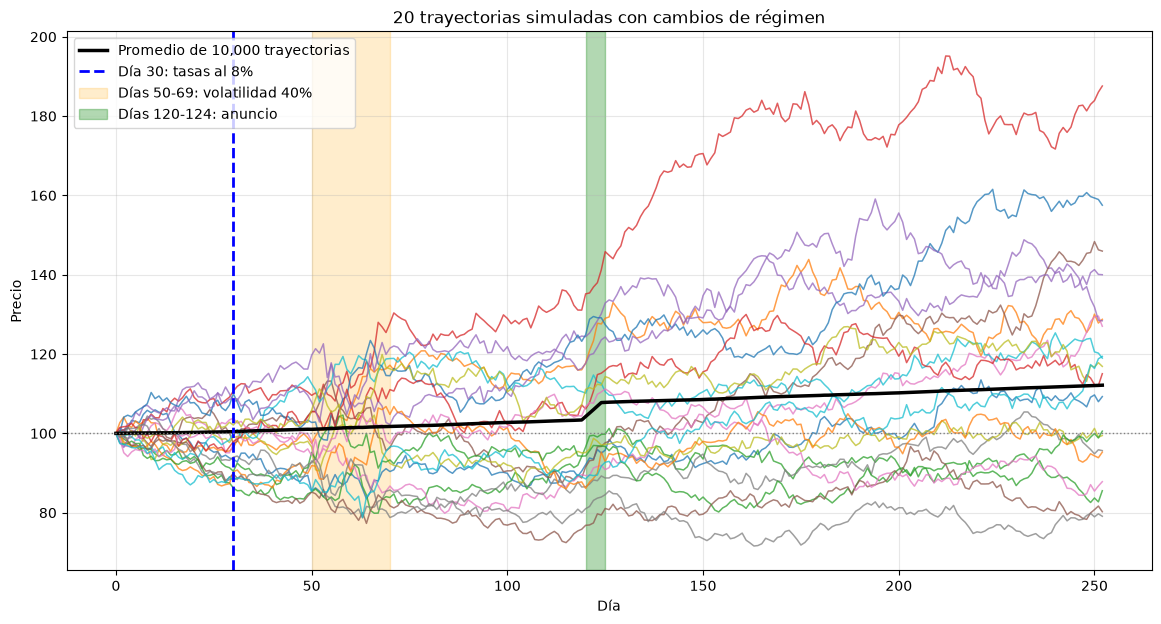

In [9]:
dias = np.arange(n + 1)

plt.figure(figsize=(14, 7))

for i in range(20):
    plt.plot(dias, S[i, :], lw=1.1, alpha=0.75)

plt.plot(dias, S.mean(axis=0), color="black", lw=2.5, label="Promedio de 10,000 trayectorias")

plt.axvline(dia_tasas, color="blue", ls="--", lw=2, label="Día 30: tasas al 8%")
plt.axvspan(dia_vol_ini, dia_vol_fin, color="orange", alpha=0.2, label="Días 50-69: volatilidad 40%")
plt.axvspan(dia_anun_ini, dia_anun_fin, color="green", alpha=0.3, label="Días 120-124: anuncio")

plt.axhline(S0, color="gray", ls=":", lw=1)
plt.xlabel("Día")
plt.ylabel("Precio")
plt.title("20 trayectorias simuladas con cambios de régimen")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

### Comparación contra un GBM estándar

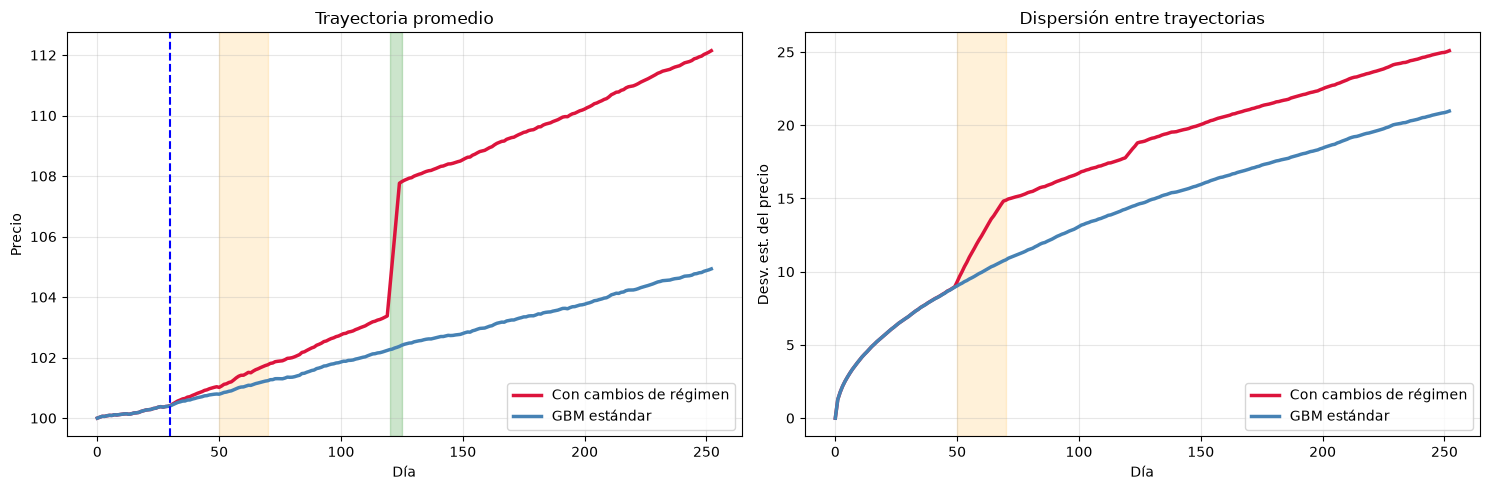

E[S_T] con cambios : 112.14   desv. est. 25.09
E[S_T] GBM estándar: 104.93   desv. est. 20.97


In [10]:
np.random.seed(42)
Z_base = np.random.normal(0, 1, (M, n))
S_base = np.zeros((M, n + 1))
S_base[:, 0] = S0

for t in range(1, n + 1):
    S_base[:, t] = S_base[:, t-1] * np.exp((r_base - 0.5*sigma_base**2)*dt
                                           + sigma_base*np.sqrt(dt)*Z_base[:, t-1])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(dias, S.mean(axis=0), color="crimson", lw=2.5, label="Con cambios de régimen")
axes[0].plot(dias, S_base.mean(axis=0), color="steelblue", lw=2.5, label="GBM estándar")
axes[0].axvline(dia_tasas, color="blue", ls="--", lw=1.5)
axes[0].axvspan(dia_vol_ini, dia_vol_fin, color="orange", alpha=0.15)
axes[0].axvspan(dia_anun_ini, dia_anun_fin, color="green", alpha=0.2)
axes[0].set_title("Trayectoria promedio")
axes[0].set_xlabel("Día"); axes[0].set_ylabel("Precio")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(dias, S.std(axis=0), color="crimson", lw=2.5, label="Con cambios de régimen")
axes[1].plot(dias, S_base.std(axis=0), color="steelblue", lw=2.5, label="GBM estándar")
axes[1].axvspan(dia_vol_ini, dia_vol_fin, color="orange", alpha=0.15)
axes[1].set_title("Dispersión entre trayectorias")
axes[1].set_xlabel("Día"); axes[1].set_ylabel("Desv. est. del precio")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"E[S_T] con cambios : {S[:, -1].mean():.2f}   desv. est. {S[:, -1].std():.2f}")
print(f"E[S_T] GBM estándar: {S_base[:, -1].mean():.2f}   desv. est. {S_base[:, -1].std():.2f}")

---
## Conclusiones

**Ejercicio 1.** El contrato se activa con la Ruta A. Ambas rutas llegan al mismo precio final, pero solo la A lo hace de forma estable. La volatilidad mide cómo se recorrió el camino, algo que el rendimiento acumulado no captura.

**Ejercicio 2.** El precio esperado al final del año sube de alrededor de 105 en el GBM estándar a alrededor de 112 con los cambios de régimen. Cada evento actúa de forma distinta:

- **Las tasas y el anuncio mueven el nivel.** Cambian hacia dónde va el precio, no qué tan disperso queda. En la gráfica del promedio se ve como un cambio de pendiente desde el día 30 y un escalón alrededor del día 120.
- **La volatilidad mueve la dispersión.** En la gráfica de desviación estándar se ve el salto entre los días 50 y 70, y que después de esa ventana la curva queda permanentemente por arriba del GBM estándar: el choque de volatilidad es temporal, pero su efecto sobre la dispersión es permanente.

La validación por tramos confirma que cada cambio entró en su ventana: volatilidad realizada de 0.20 fuera del choque, cercana a 0.40 dentro, y de 0.20 durante la semana del anuncio, que es lo correcto porque ese evento afecta la dirección y no la incertidumbre.

Simular día por día es lo que permite incorporar esta información. Con la fórmula de un solo salto de $S_0$ a $S_T$ no habría forma de meter eventos que ocurren en fechas específicas.

---

# Parte teórica: correcciones

**Nombre:** Andre Esteban Vera  
**Fecha:** 10/04/2026

---

## 1. Trayectorias

| Día | A | B | C |
|---|---|---|---|
| 0 | 100 | 100 | 100 |
| 1 | 95 | 130 | 110 |
| 2 | 105 | 80 | 112 |
| 3 | 85 | 140 | 113 |
| 4 | 120 | 90 | 114 |
| 5 | 115 | 115 | 115 |

Considera $K = 100$.

### a) Calcula el payoff para call y put de tipo europea, asiática y lookback con strike flotante para cada una de las trayectorias.

**¿Cuál es la corrección?**

Con $K = 100$ y $S_T = 115$ (las tres trayectorias terminan en 115). Para la asiática se usa el promedio aritmético de los días 0 a 5 con strike fijo $K$; para la lookback de strike flotante, call $= S_T - \min(S)$ y put $= \max(S) - S_T$.

| Opción | A | B | C |
|---|---|---|---|
| Europea call | 15 | 15 | 15 |
| Europea put | 0 | 0 | 0 |
| Asiática call | 3.33 | 9.17 | 10.67 |
| Asiática put | 0 | 0 | 0 |
| Lookback call | 30 | 35 | 15 |
| Lookback put | 5 | 25 | 0 |

- **Europea:** call $= \max(S_T - K, 0) = 15$ y put $= \max(K - S_T, 0) = 0$ para A, B y C.
- **Asiática:** promedios A $= 620/6 = 103.33$, B $= 655/6 = 109.17$, C $= 664/6 = 110.67$; call $=$ promedio $- 100$, put $= 0$ en los tres casos.
- **Lookback:** A (mín 85, máx 120): call 30, put 5; B (mín 80, máx 140): call 35, put 25; C (mín 100, máx 115): call 15, put 0.

**¿Cómo se puede evitar este error en el futuro?**

Antes de calcular escribo arriba de la tabla qué precio usa cada opción (final, promedio o extremo) y qué días cuento. Luego reviso un caso que conozco: si las tres trayectorias terminan igual, la europea tiene que dar lo mismo en las tres. Si no da, algo está mal.

### b) ¿Cuál de los tres tipos de opciones contiene más información sobre la trayectoria? Justifica.

La europea es la que menos información contiene: sólo depende de $S_T$, por eso da el mismo payoff (15 y 0) para tres trayectorias muy distintas. La lookback depende de los extremos (máximo y mínimo), por lo que distingue la trayectoria volátil B de la estable C, pero ignora lo que ocurre entre esos puntos. La asiática es la que contiene más información, porque su payoff depende de todos los precios observados a través del promedio: cualquier cambio en cualquier día modifica el payoff.

**¿Cómo se puede evitar este error en el futuro?**

Es fácil confundir "usa más puntos" con "es más sensible al camino". Lo que me sirve es ver mis propios resultados antes de contestar. Si una opción da el mismo payoff en trayectorias muy distintas, no está viendo el camino. Si los payoffs cambian mucho entre trayectorias, sí lo está viendo. La respuesta sale de la tabla, no de memoria.

---

## 2. Opciones sobre la misma acción

| Opción | Delta | Vega | Theta |
|---|---|---|---|
| A | 0.85 | 0.05 | -0.10 |
| B | 0.5 | 0.25 | -0.03 |
| C | 0.2 | 0.40 | -0.01 |

### a) Si esperas que la acción suba de manera sostenida, ¿qué opción elegirías y por qué?

La opción A, porque tiene la delta más alta (0.85): por cada \$1 que sube la acción, su valor sube aprox. \$0.85. En una subida sostenida lo que domina la ganancia es la delta; su theta (−0.10) es la mayor pérdida por tiempo, pero queda compensada si la subida se da como se espera.

**¿Cómo se puede evitar este error en el futuro?**

El error común es irse directo a la delta más alta sin pensar en el costo. Para evitarlo, reviso las tres griegas de cada opción en la misma fila y me pregunto qué gano y qué pago en el escenario que me plantean. Hacer una cuenta rápida ayuda: si sube 10 pesos, cuánto gana cada opción, y cuánto pierde por theta en el mismo tiempo.

### b) Si sabes que habrá un anuncio importante que puede provocar fuertes cambios, ¿qué opción elegirías y por qué?

La opción C, porque tiene la vega más alta (0.40): es la más sensible a un aumento de la volatilidad que genera el anuncio. Además, su delta baja (0.2) la expone poco a la dirección del movimiento (que no se conoce) y su theta (−0.01) es la menor, así que esperar al anuncio le cuesta poco.

**¿Cómo se puede evitar este error en el futuro?**

Aquí el error es tratar un anuncio como si fuera una apuesta a que sube. Lo que me sirve es separar primero si el escenario me dice la dirección o solo que habrá movimiento. Si solo sé que habrá movimiento, busco la vega más alta y la delta más baja. Si me dice la dirección, entonces sí veo delta.

### c) Explica con tus palabras qué significa que las Greeks sean sólo sensibilidades locales.

Las Greeks son derivadas parciales del precio de la opción evaluadas en las condiciones actuales (precio, volatilidad, tiempo). Sólo aproximan bien el cambio en el valor ante movimientos pequeños de una variable a la vez, manteniendo las demás constantes. Si el subyacente o la volatilidad se mueven mucho, o pasa el tiempo, las propias Greeks cambian (por ejemplo, la delta cambia según la gamma), y la aproximación lineal deja de ser válida; por eso hay que recalcularlas continuamente.

**¿Cómo se puede evitar este error en el futuro?**

Es fácil quedarse con una definición memorizada. Para evitarlo, lo compruebo con números: calculo el precio con Black-Scholes, muevo S un poco y luego mucho, y comparo contra lo que predice la delta. Ver que con 1 peso le atina y con 20 se equivoca por 3 me deja la idea clara sin tener que memorizarla.

---

## 3. Valuación con datos históricos

Un modelo con datos históricos produce para una opción $V = 15$, con un intervalo de confianza ($\alpha = 0.05$) $[14, 16]$. Seis meses después se ejerce la acción para un payoff de 80.

### a) ¿La diferencia entre el payoff y el valor calculado significa que estaba mal implementada la simulación Monte Carlo?

No. Monte Carlo estima el valor esperado (descontado, bajo la medida neutral al riesgo) del payoff, no el payoff que se va a observar. El 80 es una sola realización de una distribución que puede ser muy amplia; que caiga lejos de 15 es perfectamente posible aunque la simulación esté bien implementada. A lo mucho podría sugerir un problema de modelo (por ejemplo, volatilidad histórica subestimada), pero una sola observación no basta para concluirlo.

**¿Cómo se puede evitar este error en el futuro?**

El error es comparar un resultado individual contra un promedio. Para evitarlo, cuando el resultado real no se parece a lo estimado, me pregunto primero si estoy comparando lo mismo. Ayuda graficar el histograma de los payoffs simulados y ubicar ahí el 80. Si cae dentro de la distribución, aunque sea en la cola, no hay error de implementación.

### b) ¿Qué mide realmente el intervalo de confianza?

Mide la precisión numérica del estimador Monte Carlo: con 95% de confianza, el verdadero valor esperado que implica el modelo (con sus supuestos y parámetros) está entre 14 y 16. Refleja sólo el error de muestreo por usar un número finito de simulaciones; no es un intervalo para el payoff futuro ni cubre el riesgo de que el modelo o los datos históricos sean incorrectos.

**¿Cómo se puede evitar este error en el futuro?**

Es fácil leer el intervalo como el rango donde va a caer el resultado. Para evitarlo, siempre escribo a la par del intervalo de qué es: "intervalo del precio estimado" y no "intervalo del payoff". También ayuda calcular ambas cosas en el mismo notebook: el IC del precio y los percentiles del payoff. Al ver que uno mide 2 y el otro mide 50, la diferencia queda clara.

### c) ¿Incrementar el número de simulaciones resolvería este problema? Justifique.

No. Aumentar $N$ reduce el ancho del intervalo (el error estándar disminuye proporcional a $1/\sqrt{N}$), así que el estimador converge con más precisión al valor que da el modelo. Pero no reduce la variabilidad del payoff real ni corrige errores del modelo (supuestos de distribución, volatilidad o drift mal estimados con datos históricos). La diferencia entre 15 y 80 viene de la aleatoriedad del resultado y/o del riesgo de modelo, no del error numérico.

**¿Cómo se puede evitar este error en el futuro?**

El error es pensar que más simulaciones arreglan cualquier cosa. Para evitarlo, antes de subir M me pregunto si el problema es ruido o si es el modelo. Una prueba práctica es correr con M más grande y ver si el resultado se mueve. Si el precio casi no cambia, el problema no es el número de simulaciones, y hay que revisar los supuestos, como la volatilidad o la posibilidad de saltos.